## Importation des librairies

Nous importons les bibliothèques nécessaires pour l'analyse des données
et la visualisation graphique.

In [3]:
import numpy as np
np.set_printoptions(threshold=10000, suppress=True)

import pandas as pd
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

## Question 1 : Importation du jeu de données

Le fichier `villes.csv` contient 32 villes françaises décrites
par leurs températures moyennes pour les 12 mois de l'année.

Nous importons ces données avec la librairie pandas.

In [4]:
data = pd.read_csv('./villes.csv', sep=';')

X = data.iloc[:, 1:13].values
labels = data.iloc[:, 0].values

data.head()

,ville,janv,fev,mars,avril,mai,juin,juil,aout,sept,oct,nov,dec
0,ajac,7.7,8.7,10.5,12.6,15.9,19.8,22.0,22.2,20.3,16.3,11.8,8.7
1,ange,4.2,4.9,7.9,10.4,13.6,17.0,18.7,18.4,16.1,11.7,7.6,4.9
2,ango,4.6,5.4,8.9,11.3,14.5,17.2,19.5,19.4,16.9,12.5,8.1,5.3
3,besa,1.1,2.2,6.4,9.7,13.6,16.9,18.7,18.3,15.5,10.4,5.7,2.0
4,biar,7.6,8.0,10.8,12.0,14.7,17.8,19.7,19.9,18.5,14.8,10.9,8.2


## Question 2 : Réalisation d'une ACP

Nous appliquons une Analyse en Composantes Principales (ACP)
sur les données centrées et réduites afin d'analyser la structure
du jeu de données.

### Question 2a : Nombre d’axes à retenir

Afin de déterminer le nombre d’axes principaux à conserver,
nous analysons la variance expliquée par chaque composante principale.

L’objectif est de retenir le plus petit nombre d’axes permettant
de conserver au moins 90 % de l’information totale.

In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [7]:
variance = pca.explained_variance_ratio_
variance

array([0.87268193, 0.11720602, 0.00469563, 0.00264791, 0.00113528,
       0.00050136, 0.00042289, 0.00032817, 0.00015166, 0.00011764,
       0.00008364, 0.00002786])

In [8]:
np.cumsum(variance)

array([0.87268193, 0.98988795, 0.99458358, 0.99723149, 0.99836677,
       0.99886814, 0.99929103, 0.9996192 , 0.99977086, 0.9998885 ,
       0.99997214, 1.        ])

### Conclusion

Nous observons la variance expliquée par chaque composante principale.

La première composante explique environ 87,3 % de la variance totale,
et la deuxième environ 11,7 %.

En additionnant ces deux valeurs, nous obtenons :

87,3 % + 11,7 % ≈ 98,9 %

La somme des variances expliquées par les deux premiers axes dépasse donc
le seuil de 90 % demandé.

Nous pouvons ainsi conclure que **les deux premiers axes principaux
suffisent pour conserver plus de 90 % de l’information du nuage initial**.

### Question 2b : Application de l'ACP

Nous appliquons l’Analyse en Composantes Principales (ACP) sur les données
préalablement standardisées afin de réduire la dimension du jeu de données
tout en conservant un maximum d’information.

### Interprétation des deux premiers axes

Les données utilisées correspondent aux températures moyennes mensuelles de différentes villes françaises.

Le **premier axe principal** semble représenter un **niveau global de température moyenne annuelle**. Les villes situées du côté positif de cet axe correspondent généralement à des villes plus chaudes, souvent situées dans le sud de la France ou sur le littoral méditerranéen. À l’inverse, les villes situées du côté négatif correspondent plutôt à des villes du nord ou de l’est de la France, où les températures moyennes sont globalement plus basses.

Le **deuxième axe principal** semble représenter une **différence dans la variation saisonnière des températures**. Certaines villes présentent des écarts importants entre les températures d’été et d’hiver, tandis que d’autres ont des températures plus modérées et relativement stables tout au long de l’année.

Ainsi, ces deux axes permettent de distinguer différents profils climatiques parmi les villes étudiées.

### Question 2c : Visualisation des villes projetées dans le plan principal

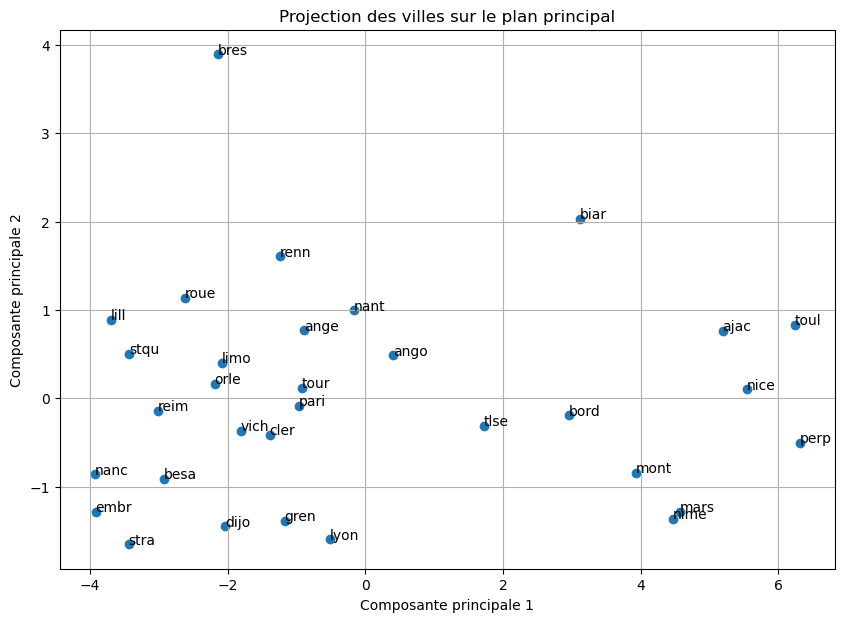

In [11]:
plt.figure(figsize=(10,7))
plt.scatter(X_pca[:, 0], X_pca[:, 1])

for l, x, y in zip(labels, X_pca[:, 0], X_pca[:, 1]):
    plt.annotate(l, xy=(x, y), xytext=(-0.2, 0.2), textcoords='offset points')

plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Projection des villes sur le plan principal")
plt.grid()
plt.show()

### Interprétation de la projection des villes dans le plan principal

Le graphique représente la projection des villes dans le plan formé par les deux premières composantes principales issues de l’Analyse en Composantes Principales (ACP).

Comme indiqué précédemment, ces deux composantes principales expliquent une grande partie de la variance totale des données. La projection des individus dans ce plan permet donc de conserver l’essentiel de l’information contenue dans les données initiales tout en facilitant leur visualisation.

Dans ce plan factoriel, chaque point correspond à une ville et sa position dépend de ses caractéristiques climatiques décrites par les températures moyennes mensuelles. Les villes proches dans ce plan possèdent des profils climatiques similaires selon les variables étudiées, tandis que les villes éloignées présentent des caractéristiques climatiques plus différentes.

On peut ainsi observer certains regroupements de villes ayant des comportements climatiques proches. Par exemple, les villes situées dans le sud de la France, comme Marseille, Nice ou Montpellier, ont tendance à se regrouper car elles présentent des températures plus élevées sur l’ensemble de l’année, en particulier durant les mois d’été.

À l’inverse, certaines villes du nord ou de l’est de la France, comme Lille ou Strasbourg, peuvent apparaître dans une zone opposée du graphique. Ces villes se caractérisent généralement par des températures moyennes plus basses, notamment pendant les mois d’hiver.

Les villes de l’ouest de la France, comme Brest ou Nantes, peuvent quant à elles occuper une position intermédiaire dans le graphique. Leur climat océanique est en effet caractérisé par des températures plus modérées et par une amplitude thermique plus faible entre l’hiver et l’été.

Ainsi, la projection des villes dans le plan principal permet de mettre en évidence différentes structures climatiques et d’identifier visuellement plusieurs profils climatiques parmi les villes françaises.

### Question 2d : Projection des villes dans le plan principal

Nous représentons les villes dans le plan formé par
les deux premiers axes principaux.

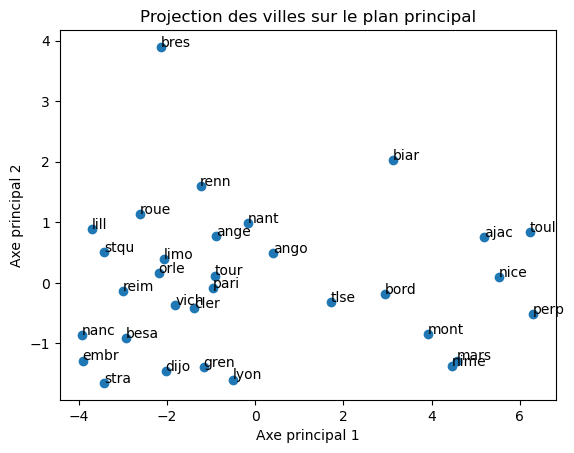

In [12]:
plt.scatter(X_pca[:, 0], X_pca[:, 1])

for l, x, y in zip(labels, X_pca[:, 0], X_pca[:, 1]):
    plt.annotate(l, xy=(x, y), xytext=(-0.2, 0.2), textcoords='offset points')

plt.xlabel("Axe principal 1")
plt.ylabel("Axe principal 2")
plt.title("Projection des villes sur le plan principal")

plt.show()

### Analyse de la projection des villes dans le plan principal

La projection des villes dans le plan formé par les deux premières composantes principales permet de visualiser la structure des données et d’identifier les relations entre les différentes villes selon leurs caractéristiques climatiques.

Dans ce plan factoriel, les villes proches possèdent des profils climatiques similaires, tandis que les villes éloignées présentent des comportements climatiques différents. La distance entre les points traduit donc la similarité ou la dissemblance entre les villes en termes de températures moyennes mensuelles.

Le premier axe principal semble traduire un **gradient global de température**. Les villes situées du côté droit du graphique correspondent généralement à des villes plus chaudes, souvent localisées dans le sud de la France ou sur le littoral méditerranéen. Ces villes bénéficient d’un climat plus chaud et présentent des températures élevées durant une grande partie de l’année. On peut par exemple citer Marseille, Nice ou Montpellier.

À l’inverse, les villes situées du côté gauche du graphique correspondent plutôt à des villes du nord ou de l’est de la France, caractérisées par des températures plus faibles, notamment en hiver. Des villes comme Lille, Strasbourg ou Nancy peuvent ainsi se situer dans cette zone du graphique.

Le deuxième axe principal semble quant à lui traduire une **différence dans la variation saisonnière des températures**. Certaines villes peuvent présenter des écarts importants entre les températures hivernales et estivales, tandis que d’autres ont des températures plus modérées tout au long de l’année.

Les villes situées dans l’ouest de la France, influencées par le climat océanique, comme Brest ou Nantes, peuvent apparaître dans une position intermédiaire dans le graphique. Leur climat est généralement caractérisé par des hivers relativement doux et des étés modérés, ce qui entraîne une amplitude thermique plus faible.

La structure du nuage de points montre donc une certaine organisation des villes selon leur localisation géographique et leur climat. On peut ainsi identifier plusieurs groupes correspondant à des **profils climatiques distincts**, notamment les villes méditerranéennes, les villes du nord ou de l’est au climat plus froid, et les villes de l’ouest caractérisées par un climat océanique plus tempéré.

Ainsi, l’ACP permet de mettre en évidence une typologie des villes françaises basée sur leurs caractéristiques climatiques et facilite l’interprétation des relations entre les différentes observations.

## Question 2e : Fonction regroupant les étapes de l'ACP

Nous définissons une fonction permettant de regrouper les principales étapes
de l'analyse en composantes principales :

- standardisation des données
- application de l'ACP
- projection des individus sur le plan principal
- affichage du graphique

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def analyse_pca(data, labels):
    
    # Standardisation des données
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(data)

    # Application de l'ACP
    pca = PCA()
    X_pca = pca.fit_transform(X_scaled)

    # Affichage de la projection
    plt.figure(figsize=(10,7))
    plt.scatter(X_pca[:, 0], X_pca[:, 1])

    for l, x, y in zip(labels, X_pca[:, 0], X_pca[:, 1]):
        plt.annotate(l, xy=(x, y), xytext=(-0.2, 0.2), textcoords='offset points')

    plt.xlabel("Axe principal 1")
    plt.ylabel("Axe principal 2")
    plt.title("Projection des individus sur le plan principal")

    plt.show()

    return pca.explained_variance_ratio_

## Question 3 : Application de l'ACP sur le jeu de données `crimes.csv`

Le fichier `crimes.csv` contient des statistiques de criminalité dans 50 états américains.

Nous appliquons la fonction d'ACP définie précédemment afin de visualiser les états
dans le plan principal et d'identifier d'éventuels regroupements.

In [14]:
crimes = pd.read_csv('./crimes.csv', sep=';')

crimes.head()

,Etat,Meutre,Rapt,Vol,Attaque,Viol,Larcin,Auto_Theft
0,Alabama,14.2,25.2,96.8,278.3,1135.5,1881.9,280.7
1,Alaska,10.8,51.6,96.8,284.0,1331.7,3369.8,753.3
2,Arizona,9.5,34.2,138.2,312.3,2346.1,4467.4,439.5
3,Arkansas,8.8,27.6,83.2,203.4,972.6,1862.1,183.4
4,California,11.5,49.4,287.0,358.0,2139.4,3499.8,663.5


In [15]:
X_crimes = crimes.iloc[:, 1:].values
labels_crimes = crimes.iloc[:, 0].values

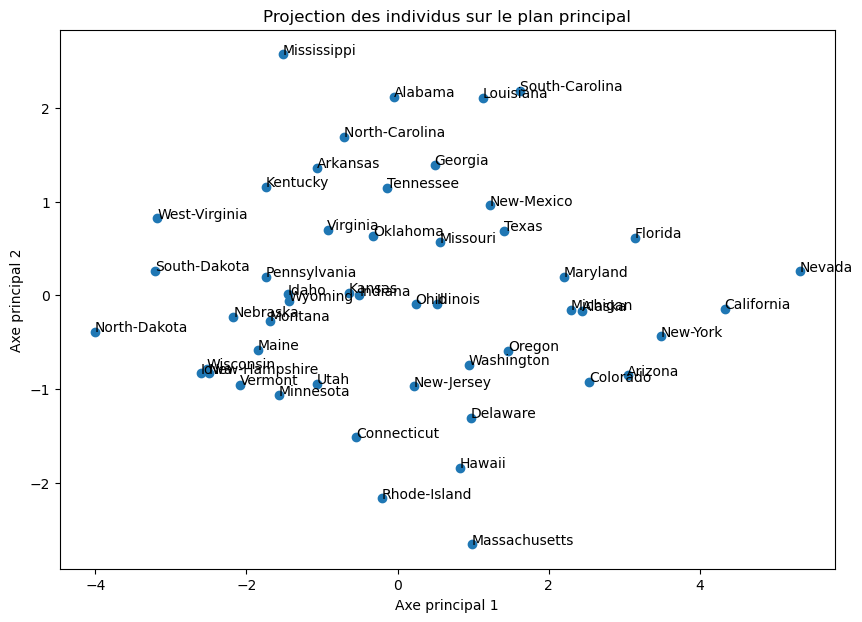

array([0.58785136, 0.17696026, 0.10368809, 0.04520458, 0.03685349,
       0.03171992, 0.01772229])

In [16]:
analyse_pca(X_crimes, labels_crimes)

### Interprétation et comparaison

La projection des états américains dans le plan formé par les deux premières composantes principales permet de visualiser les relations entre les états selon leurs profils de criminalité.

Dans ce plan factoriel, les états proches possèdent des caractéristiques criminelles similaires, tandis que les états éloignés présentent des profils de criminalité plus différents. La distance entre les points traduit donc la similarité ou la différence entre les états en termes de types et de niveaux de crimes observés.

Le **premier axe principal** semble représenter un **niveau global de criminalité**. Les états situés d’un côté de cet axe correspondent généralement à des états présentant des taux élevés pour plusieurs types de crimes (meurtres, agressions, vols ou viols). Ces états peuvent correspondre à des zones fortement urbanisées où la criminalité est plus importante. À l’inverse, les états situés de l’autre côté de l’axe présentent des niveaux de criminalité plus faibles et correspondent souvent à des états plus ruraux ou moins densément peuplés.

Le **deuxième axe principal** semble traduire une **différence dans la nature des crimes observés**. Certains états peuvent être caractérisés par une proportion plus importante de crimes violents (meurtres, agressions ou viols), tandis que d’autres présentent davantage de délits liés aux vols, comme les larcins ou les vols de voitures. Cet axe permet donc de distinguer différents types de profils criminels.

La projection met ainsi en évidence une structure plus hétérogène que dans le cas des villes étudiées précédemment. Alors que les villes françaises se regroupaient principalement selon leur climat, les états américains se distinguent ici selon des facteurs socio-économiques, démographiques et urbains qui influencent les niveaux et les types de criminalité.

Ainsi, l’ACP permet d’identifier plusieurs **typologies d’états**, opposant par exemple des états fortement urbanisés avec des niveaux élevés de criminalité à des états plus ruraux caractérisés par des niveaux de criminalité plus faibles.

## Question 4 : Application de l'ACP sur le jeu de données 50_Startups.csv

Le fichier `50_Startups.csv` contient des informations sur 50 startups
américaines décrites par leurs dépenses en :

- R&D
- Administration
- Marketing

ainsi que leur bénéfice annuel.

Nous appliquons la même fonction d'ACP afin d'observer
les relations entre ces variables et identifier d'éventuels regroupements.

In [17]:
startups = pd.read_csv('./50_Startups.csv', sep=';')
startups.head()

,Id,Depenses R&D,Depenses Administration,Depenses Marketing Spend,Benefice
0,1,165349.20,136897.80,471784.10,192261.83
1,2,162597.70,151377.59,443898.53,191792.06
2,3,153441.51,101145.55,407934.54,191050.39
3,4,144372.41,118671.85,383199.62,182901.99
4,5,142107.34,91391.77,366168.42,166187.94


In [18]:
startups.columns

Index(['Id', 'Depenses R&D', 'Depenses Administration',
       'Depenses Marketing Spend', 'Benefice'],
      dtype='object')

In [19]:
X_startups = startups.iloc[:, 1:].values
labels_startups = startups.iloc[:, 0].values

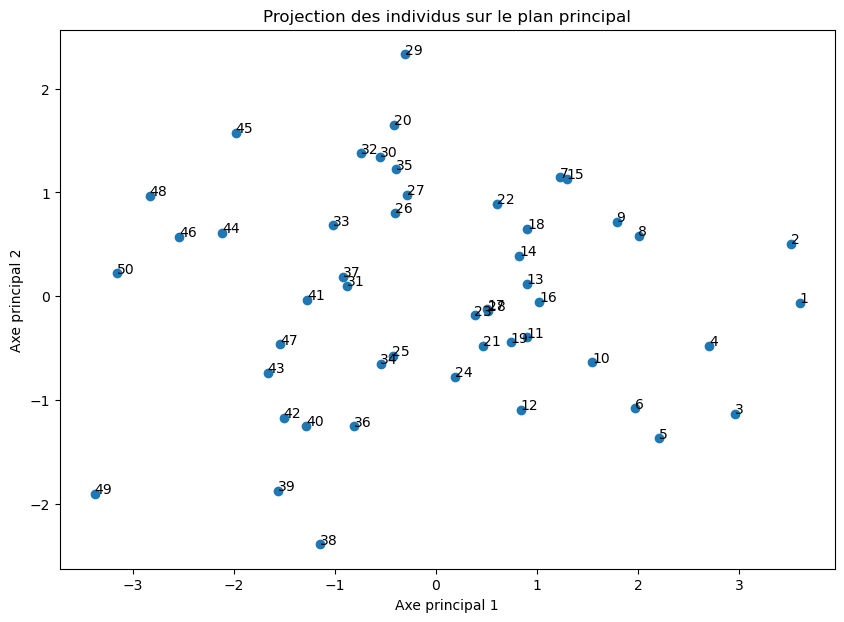

array([0.66804393, 0.25484695, 0.07063561, 0.00647351])

In [20]:
analyse_pca(X_startups, labels_startups)

### Interprétation

La projection des startups dans le plan formé par les deux premières composantes principales permet d’analyser les relations entre les différentes variables économiques du jeu de données, à savoir les dépenses en recherche et développement (R&D), en administration, en marketing, ainsi que le bénéfice annuel.

Dans ce plan factoriel, chaque point représente une startup. Les startups proches dans le graphique présentent des profils économiques similaires, c’est-à-dire des niveaux de dépenses et de bénéfices comparables. À l’inverse, les startups éloignées possèdent des structures d’investissement ou des performances financières différentes.

Le **premier axe principal** semble représenter un **niveau global d’investissement et de performance économique**. Les startups situées d’un côté de cet axe correspondent généralement à des entreprises investissant davantage dans leurs activités (notamment en R&D et en marketing) et pouvant générer un bénéfice plus élevé. À l’inverse, les startups situées de l’autre côté de l’axe correspondent plutôt à des entreprises ayant des niveaux d’investissement plus faibles et des performances économiques plus limitées.

Le **deuxième axe principal** semble quant à lui traduire une **différence dans la structure des dépenses**. Certaines startups peuvent consacrer une part importante de leurs ressources à la recherche et développement afin d’innover et de développer de nouveaux produits, tandis que d’autres peuvent investir davantage dans le marketing ou dans les activités administratives pour soutenir leur croissance commerciale.

La projection des startups dans le plan principal permet donc d’identifier différentes stratégies d’investissement entre les entreprises. Certaines startups privilégient l’innovation et la R&D, tandis que d’autres concentrent leurs dépenses sur le marketing ou la gestion administrative.

Ainsi, l’ACP met en évidence plusieurs **profils de startups**, caractérisés par des structures de dépenses différentes et par des niveaux de performance économique variables.